<a href="https://colab.research.google.com/github/Kedar154/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.express as px
%matplotlib inline

In [2]:
!pip install opendatasets
!pip install legacy-cgi
import opendatasets as od
od.download('https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?select=creditcard.csv')

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


100%|██████████| 66.0M/66.0M [00:00<00:00, 1.74GB/s]

In [3]:
data = pd.read_csv('/content/creditcardfraud/creditcard.csv')

In [4]:
print(data.head())
print(data.info())
print(data.describe())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Test Train Split

In [5]:
from sklearn.model_selection import train_test_split as tts
train, test = tts(data, test_size = 0.2, random_state = 42)
train, val = tts(train, test_size = 0.1, random_state = 42)

train_inp = train.drop('Class', axis = 1)
train_out = train['Class']
val_inp = val.drop('Class', axis = 1)
val_out = val['Class']
test_inp = test.drop('Class', axis = 1)
test_out = test['Class']

In [29]:
train

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
263162,160825.0,-4.459943,3.391938,-4.478389,0.367790,-1.640816,-2.213569,-1.720566,2.972910,-0.558610,...,0.415366,0.574676,0.226970,-0.187679,-0.210670,-0.162370,-0.710094,-0.415211,1.00,0
170890,120398.0,1.902335,-0.779996,-0.519762,-0.642167,-0.977215,-1.005467,-0.461400,-0.224221,1.439524,...,0.232891,0.721215,0.106058,0.143587,-0.342290,0.691905,-0.046964,-0.037033,82.80,0
200686,133532.0,0.574872,-3.302970,-1.047675,-0.278139,-1.501658,0.976159,-0.429658,0.219368,1.710061,...,0.642196,0.281505,-0.461173,-0.019691,-0.823258,0.797806,-0.164806,0.075901,749.86,0
114743,73607.0,-0.879383,1.138867,0.834804,0.904867,0.164135,-0.486903,0.286551,0.437374,-0.751725,...,0.208368,0.597398,-0.073658,0.098907,-0.232732,-0.289270,0.314182,0.120301,11.80,0
51209,44841.0,1.097978,-1.697272,-0.243600,-1.211995,-1.364530,-0.472837,-0.529240,-0.183287,-2.026078,...,-0.053846,-0.170205,-0.322497,0.014244,0.601802,-0.082437,-0.030393,0.032154,227.40,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131478,79616.0,-0.877913,-0.301831,2.735473,1.253404,-1.145942,0.068037,-0.076945,0.179777,0.601691,...,0.264666,0.931641,0.143916,1.033013,-0.117342,0.753320,0.104314,0.152018,133.50,0
239193,150000.0,-1.662279,-0.278422,2.677875,1.479724,-0.641821,0.421010,-1.162016,0.946243,0.705521,...,0.318863,0.747940,-0.328271,-0.004766,0.429288,-0.220109,0.057000,-0.105868,37.90,0
67705,52666.0,-1.061497,0.978902,1.629268,-1.385857,-0.074805,-1.054468,0.893588,-0.304963,0.396304,...,-0.191385,-0.143821,-0.080626,0.448429,-0.230180,0.697131,0.306224,0.115183,25.00,0
233557,147611.0,2.081836,-0.128730,-1.497688,0.049290,0.463113,-0.260199,0.090636,-0.139337,0.305002,...,-0.300450,-0.762338,0.183893,-1.088678,-0.175748,0.243605,-0.075166,-0.079110,8.99,0


## XGB + RF

In [7]:
from xgboost import XGBClassifier as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [8]:
train['Class'].value_counts()

,count
Class,
0,204701
1,359


Training without Balancing CLasses

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [10]:
model = xgb(n_estimators = 100, learning_rate = 0.1, max_depth = 5)
model.fit(train_inp, train_out)
print(f"F1 score Training: {f1_score(model.predict(train_inp), train_out)}")
print(f"F1 score Val: {f1_score(model.predict(val_inp), val_out)}")



F1 score Training: 0.9594202898550724
F1 score Val: 0.9230769230769231


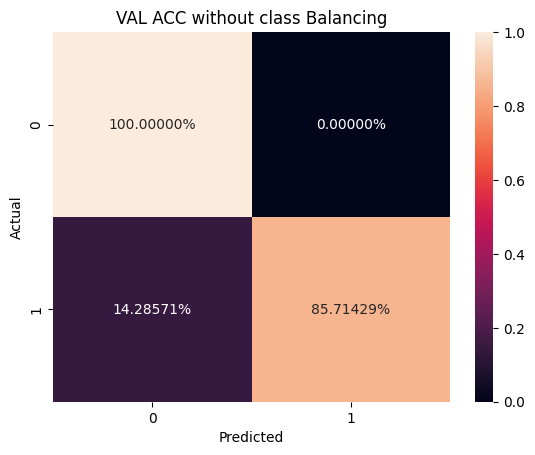

In [11]:

cfm_t = confusion_matrix(val_out, model.predict(val_inp), normalize= 'true')
sns.heatmap(cfm_t, annot = True, fmt = '.5%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('VAL ACC without class Balancing')
plt.show()

Training After Balancing Classes


In [12]:
class_ratio = len(train[train['Class']==0])/len(train[train['Class']==1])
print(class_ratio)

570.1977715877438


In [13]:
model1 = xgb(n_estimators = 100, learning_rate = 0.1, max_depth = 5, scale_pos_weight = class_ratio)
model1.fit(train_inp, train_out)
print(f"F1 score Training: {f1_score(model1.predict(train_inp), train_out)}")
print(f"F1 score Val: {f1_score(model1.predict(val_inp), val_out)}")


F1 score Training: 0.8339140534262486
F1 score Val: 0.735632183908046


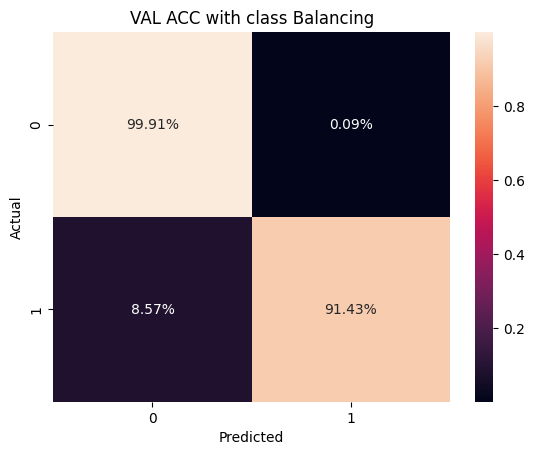

In [14]:
cfm_t = confusion_matrix(val_out, model1.predict(val_inp), normalize= 'true')
sns.heatmap(cfm_t, annot=True, fmt='.2%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('VAL ACC with class Balancing')
plt.show()

Hyper Parameter Tuning

In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [16]:
tuning = {
    'n_estimators': [],
    'max_depth': [],
    'learning_rate': [],
    'f1_score_t': [],
    'f1_score_v': []
}

In [62]:

def opt(params):

  rnd_search = RandomizedSearchCV(
    estimator = xgb(scale_pos_weight = class_ratio),
    param_distributions = params,
    n_iter = 15,
    n_jobs = -1,
    random_state = 37,
    scoring= 'average_precision'

  )

  rnd_search.fit(train_inp, train_out)
  print(f"score: {rnd_search.best_score_}")
  print(f'params: {rnd_search.best_params_}')
  print(f"F1 score train: {f1_score(rnd_search.best_estimator_.predict(train_inp), train_out)}")
  print(f"F1 score Val: {f1_score(rnd_search.best_estimator_.predict(val_inp), val_out)}")

  tuning['n_estimators'].append(rnd_search.best_params_['n_estimators'])
  tuning['max_depth'].append(rnd_search.best_params_['max_depth'])
  # Removed min_samples_split and min_samples_leaf as they are not used by XGBClassifier
  # Consider adding 'min_child_weight' here if you include it in params
  tuning['learning_rate'].append(rnd_search.best_params_['learning_rate'])
  tuning['f1_score_v'].append(f1_score(rnd_search.best_estimator_.predict(val_inp), val_out))

  return rnd_search.best_estimator_

`scoring = 'f1'` maximises F1score

`scoring = 'recall'` minimises False -ve where getting a wrong YES is very bad

`scoring = 'average_precision'` better ig?

In [67]:
params = {
    'n_estimators': [100, 125, 150],
    'max_depth': [3,5,7,9],
    'learning_rate': [.05,.1,.15, .2],
}
rnd_search = opt(params)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:12:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


score: 0.8380917379995744
params: {'n_estimators': 150, 'min_samples_split': 240, 'min_samples_leaf': 130, 'max_depth': 7, 'learning_rate': 0.1}
F1 score train: 1.0
F1 score Val: 0.9142857142857143


In [78]:
tuning

,n_estimators,max_depth,learning_rate,f1_score_v
0,200,9,0.1,0.914286
1,150,7,0.2,0.941176


Final Model Hyperparameters


In [79]:
tuning = pd.DataFrame(tuning)
print(tuning)

   n_estimators  max_depth  learning_rate  f1_score_v
0           200          9            0.1    0.914286
1           150          7            0.2    0.941176


F1 score Training: 1.0
F1 score Val: 0.9393939393939394
F1 score Test: 0.8491620111731844


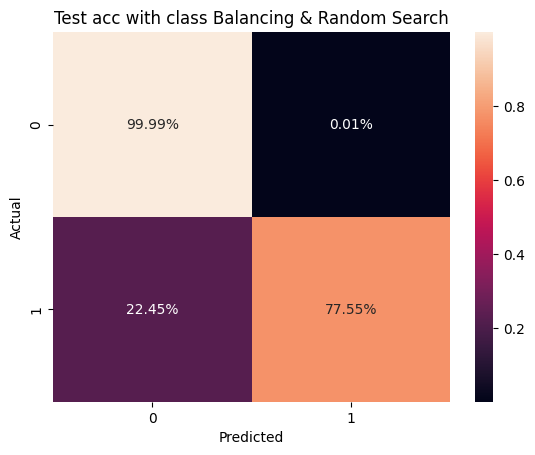

In [80]:
model = xgb(n_estimators=150, max_depth= 7, learning_rate= 0.2)
model.fit(train_inp, train_out)
print(f"F1 score Training: {f1_score(model.predict(train_inp), train_out)}")
print(f"F1 score Val: {f1_score(model.predict(val_inp), val_out)}")
print(f"F1 score Test: {f1_score(model.predict(test_inp), test_out)}")
cfm_hyp = confusion_matrix(test_out, model.predict(test_inp), normalize= 'true')
sns.heatmap(cfm_hyp, annot=True, fmt='.2%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test acc with class Balancing & Random Search')
plt.show()

Need To Improve